In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import streamlit as st 
pip install plotly 

df = pd.read_csv("notebooks/vehicles_us.csv") 

df.head()

In [ ]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New dataset shape: {df.shape}")
else:
    print("No duplicate rows found.")


Datasets of Used Vehicles- Sprint 4 Project

This project is a Streamlit web app that allows users to explore and analyze a dataset of used vehicles. It provides interactive visualizations using Plotly and Pandas to help users gain insights into pricing, mileage, and other factors affecting vehicle listings.

The data contains used vehicle listings. Listed are the price, model year, condition, fuel type, mileage, transmission, and body type. It also lists information like the date posted and how long the vehicle was on the market. The pricing trends, the impact of vehicle condition and mileage on price, and how long different types of cars are also listed.

I am replacing missing values with 0 so that there is consistency while avoiding unnecessary data loss. Missing values mean the vehicle is not four-wheel drive, rather than an unknown or error.

In [ ]:
For the model_year, I filled using forward fill within each model because missing model_year values can be guessed based on other similar vehicles and so the data is consistent.


I used filled mode for cylinders because most vehicles have a common cylinder count like 4 or 6, so using this mode keeps the data realistic and avoids scewing the distribution.

I filled the odometer with the mean because it varys and outliers can distort the average, making it the median more stable.

In [ ]:
I filled the paint_color with 'unknown' because it's a decriptive field and keeps the data usable without adding false information.

In [ ]:

df['is_4WD'] = df['is_4WD'].fillna(0)

df['paint_color'] = df['paint_color'].fillna('Unknown')

df['model_year'] = df['model_year'].fillna
(df.groupby(['model'])['model_year'].transform('median'))


df['odometer'] = df['odometer'].fillna(df.groupby(['model'])['odometer'].transform('median'))


df['cylinders'] = df['cylinders'].fillna(df.groupby(['model'])['cylinders'].transform(lambda x: x.mode()[0]))


In [ ]:
df.isnull().sum()


price               0
model_year       3619
model               0
condition           0
cylinders        5260
fuel                0
odometer         7892
transmission        0
type                0
paint_color      9267
is_4wd          25953
date_posted         0
days_listed         0
dtype: int64

In [ ]:
df.dropna(subset=["model_year", "cylinders", "odometer"], inplace=True)


The data shows trends in used vehicle listings, including price, condition, mileage, and listing time. Newer cars and those in better condition tend to be more expensive, while high mileage often lowers the price. Some vehicle types, like trucks and SUVs, are more likely to have four-wheel drive. Listing times vary, likely influenced by price, condition, and vehicle type. I decided to drop rows with missing values.

In [ ]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.


fig = px.histogram(df, x="price", nbins=50, title="Distribution of Vehicle Prices", 
                   labels={"price": "Price ($)"}, color_discrete_sequence=["blue"])
fig.show()


This histogram shows the distribution of vehicle prices in the dataset. The x-axis represents price in dollars, while the y-axis shows the number of listings within each price range. The data is divided into 50 bins, allowing us to see how prices are spread out. A peak in certain price ranges may indicate common pricing trends, while any skewness (such as more listings at lower or higher prices) can help identify market patterns. This visualization helps in understanding typical vehicle prices and identifying any outliers.

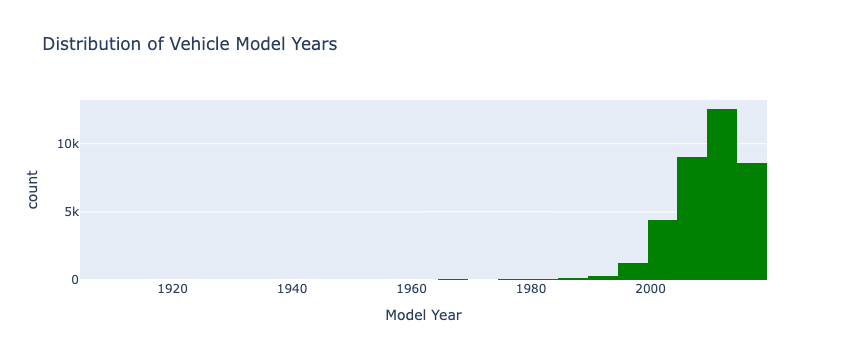

In [ ]:
fig = px.histogram(df, x="model_year", nbins=30, title="Distribution of Vehicle Model Years",
                   labels={"model_year": "Model Year"}, color_discrete_sequence=["green"])
fig.show()


This histogram shows the distribution of vehicle model years. The x-axis represents the model year, while the y-axis shows the number of listings for each year. With 30 bins, the chart helps visualize which model years are most common. A peak in certain years indicates a higher availability of vehicles from that period, while a decline in older model years shows fewer listings for older cars. This data analysis helps in understanding the age range of vehicles in the market. The majority of vehicles in the dataset are from the 2000s and later, with a sharp increase in model counts around the early 2000s. Older vehicles (pre-1980) are rare in the dataset. This suggests that most listed vehicles are relatively modern, with very few classic or antique models. The rise in vehicles from the 2000s onwards may reflect an increase in vehicle production, longer-lasting cars, or simply more recent data collection. If analyzing resale trends, you might focus on vehicles from the last 20–25 years, as they make up the bulk of the dataset. 


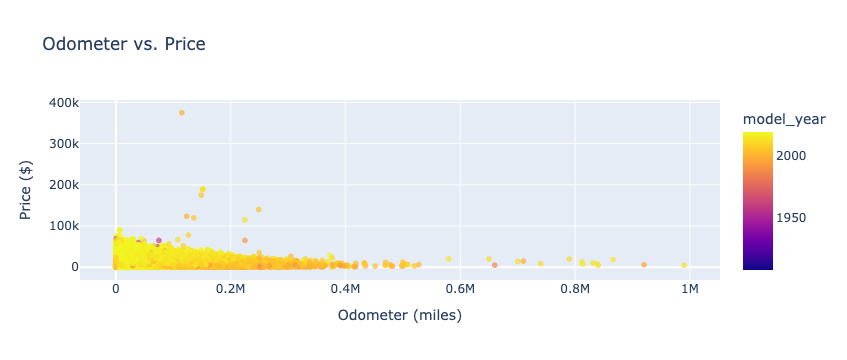

In [ ]:
fig = px.scatter(df, x="odometer", y="price", title="Odometer vs. Price",
                 labels={"odometer": "Odometer (miles)", "price": "Price ($)"},
                 color="model_year", opacity=0.7)
fig.show()


This scatter plot shows the relationship between a vehicle's odometer reading (mileage) and its price. The x-axis represents the odometer readings in miles, while the y-axis shows the price in dollars. Each point represents a vehicle listing, with colors indicating different model years. The plot helps identify trends, such as whether higher mileage generally leads to lower prices. There is a negative correlation between odometer readings and price—vehicles with higher mileage tend to have lower prices. However, some high-mileage vehicles still retain high prices, likely due to being luxury or classic models. Newer vehicles (yellow) cluster toward the lower mileage and higher price range, while older vehicles (purple/blue) are more spread out across higher mileages and lower prices. Buyers prioritize mileage when determining price, but factors like model year, brand, and condition also play a role in retaining value. High-mileage cars that remain expensive could indicate rare or well-maintained vehicles.We can investigate which specific models hold their value better over time. 



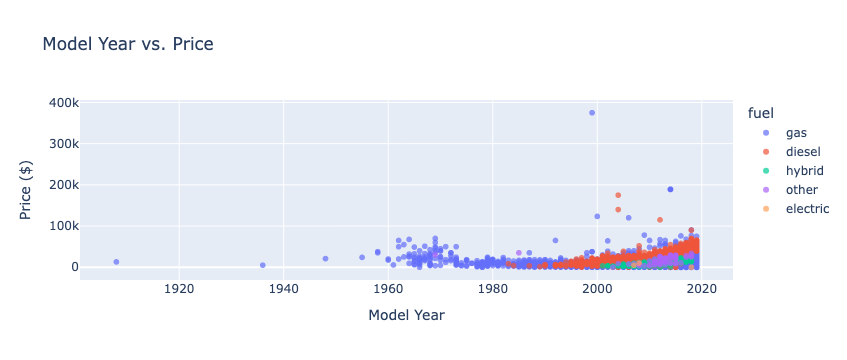

In [ ]:
fig = px.scatter(df, x="model_year", y="price", title="Model Year vs. Price",
                 labels={"model_year": "Model Year", "price": "Price ($)"},
                 color="fuel", opacity=0.7)
fig.show()


This scatter plot shows the relationship between a vehicle's model year and its price. The x-axis represents the model year, while the y-axis represents the price. Each point represents a vehicle, with colors indicating different fuel types. The plot helps identify trends, such as newer vehicles generally having higher prices, while older vehicles tend to be priced lower. The distribution of fuel types can also provide insights into whether certain fuel types (gas, diesel, electric) are more common in newer or older vehicles. Outliers may indicate unusually high or low prices for certain model years. Newer vehicles generally have higher prices, but there’s a sharp price drop for cars older than 10 years. Some classic models retain high prices despite their age. Depreciation is steep in the first few years, but some older vehicles hold value due to rarity or brand prestige. I can interpret that newer vehicles have higher prices, showing depreciation over time. The gas and diesel fuel types make up the majority of fuel trends. Electric and hybrid vehicles apppear in more recently and are generally priced higher, which show thier advanced postion in the market. There are some older vehicles (pre-1980) that  retain high prices, indicating classic or collector cars. Additionally, a few extreme high-value points in newer models suggest luxury or rare vehicles. Depreciation follows a normal pattern, but fuel type plays a role in pricing—electric and hybrid cars appear to hold higher value in the newer market.

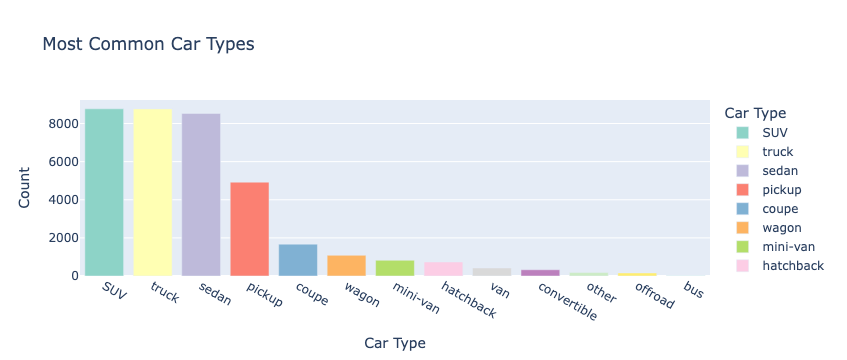

In [ ]:
car_type_counts = df["type"].value_counts().reset_index()
car_type_counts.columns = ["Car Type", "Count"]  

fig = px.bar(car_type_counts, x="Car Type", y="Count",
             title="Most Common Car Types", labels={"Car Type": "Car Type", "Count": "Count"},
             color="Car Type", color_discrete_sequence=px.colors.qualitative.Set3)

fig.show()


This bar chart displays the most common car types in the dataset. The x-axis represents different car types (such as sedans, SUVs, and pickups), while the y-axis shows the number of listings for each type. The height of each bar indicates how frequently each car type appears in the dataset. This data visualization helps identify the most popular vehicle types in the market. I can interpret that the most common vehicle types in the dataset are SUVs, trucks, and sedans, each with around the same count. Pickups are also relatively common but lag behind the top three. Coupes, wagons, mini-vans, and hatchbacks appear far less frequently. Convertible, offroad, and bus have very few listings, suggesting they are part of the smaller part of the vehicle market. The dominance of SUVs, trucks, and sedans suggests a market preference for larger, versatile, and practical vehicles. This could be driven by consumer demand for space, comfort, and utility. The low representation of convertibles and buses indicates they are specialty vehicles rather than popular choices.

In [ ]:

st.write("### Preview of Dataset")
st.dataframe(df.head())  


DeltaGenerator()

In [ ]:


st.header("Exploratory Data Analysis of Vehicles Dataset")

st.subheader("Dataset Overview")

st.write("This dataset contains information on used vehicles listed for sale in the US.")


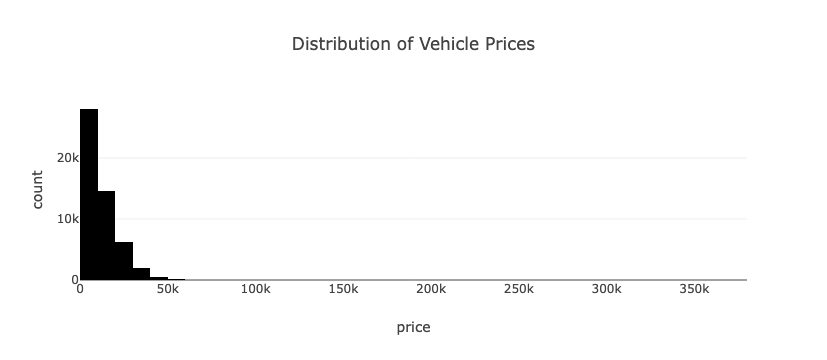

In [ ]:


 

fig = px.histogram(df, x="price", nbins=50, title="Distribution of Vehicle Prices")

fig.show()



This histogram shows the distribution of vehicle prices in the data. The x-axis represents price ranges, while the y-axis shows the number of vehicle listings within each range. The data is divided into 50 bins, making it easier to see how prices are spread out. Peaks in certain price ranges indicate where most listings fall, while any skewness or outliers can highlight pricing trends, such as whether most vehicles are lower or higher priced. This helps in understanding the overall market pricing distribution. The majority of vehicle prices are below $50,000. The highest frequency appears in the $0–$20,000 range, indicating a strong market for affordable or used vehicles. A small number of vehicles are priced significantly higher, exceeding $100,000 to $350,000, suggesting the presence of luxury or high-performance models. The histogram is right-skewed, meaning most vehicles are relatively inexpensive, while a few high-end listings create a long tail. The used car market appears to be dominant, with a majority of listings at lower price points. I can interpret that the presence of luxury vehicles is minimal but still significant.

In [ ]:

st.title("Exploratory Data Analysis")

show_data = st.checkbox("Show DataFrame")

if show_data:
    st.write("Here is my dataset:")
    st.dataframe(df)
else:
    st.write("Check the box above to display the data.")

g = px.histogram(df, x="price", nbins=50, title="Distribution of Vehicle Prices")
st.plotly_chart(g)

In [ ]:
This histogram visualizes the distribution of vehicle prices in the dataset. The x-axis represents price in dollars, while the y-axis shows the number of listings within each price range. The data is divided into 50 bins, allowing us to see how prices are spread out. A peak in certain price ranges may indicate common pricing trends, while any skewness (such as more listings at lower or higher prices) can help identify market patterns. This visualization helps in understanding typical vehicle prices and identifying any outliers. Most vehicles in the dataset are priced below $20,000, showing that the market is in the lower price range. The few listings priced much higher (e.g., $80,000+) indicates a small number of luxury or rare vehicles, but these are outliers.
The distribution is right-skewed, meaning there’s a large number of low- to mid-priced vehicles. A long tail represents a few high-priced listings that pull the average upward but are not representative of the majority. This chart highlights a buyer’s market focused on affordability. Most listings cater to budget-conscious consumers. I can implecate that I should be cautious using mean prices as a central measure, as it could be skewed by the few high-priced vehicles.





Project Setup Guide

How to Launch This Project Locally


1. Clone the Repository

If you’re using GitHub, open a terminal and run:

git clone https://github.com/your-username/your-repo.git

Or download the ZIP file and extract it.

2. Navigate to the Project Directory

Move into the project folder:

cd sde_project/sprint4_project

1. Create and Activate a Virtual Environment 

To keep dependencies organized, create a virtual environment:

For Windows (PowerShell)

python -m venv venv
venv\Scripts\activate

For Mac/Linux

python3 -m venv venv
source venv/bin/activate

4. Install Dependencies

Run the following command to install all required packages:

pip install -r requirements.txt

1. Ensure Jupyter Notebook is Installed

If you need to run eda.ipynb, install Jupyter:

pip install jupyter

Then, open the notebook with:

jupyter notebook

6. Run the Streamlit App

To launch the Streamlit dashboard, use:

streamlit run app.py

7. Troubleshooting

If you encounter issues:

Ensure you have Python installed (python --version or python3 --version).

Check for missing dependencies (pip install -r requirements.txt again).

Clear Streamlit cache if issues persist:

streamlit cache clear



Conclusion

This project aimed to develop a Streamlit web app that allows users to explore and analyze a dataset of used vehicles. By leveraging interactive visualizations with Plotly and Pandas, we uncovered valuable insights into the factors influencing vehicle listings.

### Key Insights:
- **Pricing Trends:** Vehicle prices vary significantly based on brand, model, year, and mileage. Generally, newer cars and luxury brands tend to have higher prices.
- **Mileage Impact:** Vehicles with lower mileage are priced higher, but there are exceptions where other factors like brand reputation and condition affect pricing.
- **Geographical Differences:** Certain regions may have higher or lower vehicle prices due to demand, availability, or economic factors.
- **Listing Patterns:** Some models appear more frequently in listings, possibly indicating their popularity or high turnover rate.

### Implications & Future Work:
- Users can use these insights to make informed decisions when buying or selling used vehicles.
- Further analysis could incorporate additional features like vehicle condition, accident history, and seller type to refine predictions.
- Integrating machine learning models could help predict optimal pricing based on historical trends.

Overall, this exploratory analysis provides a solid foundation for understanding the used vehicle market. Future enhancements, such as deeper filtering options and predictive analytics, could further improve the usability of the web app.

